# NB04f — LOSO Ecotype Stability (internal cross-study replication)

**Project**: `ibd_phage_targeting` — Pillar 1 + Pillar 2 strengthening
**Depends on**: NB01b (K=4 consensus ecotype assignments), NB04c (substudy resolution pipeline)

## Purpose

NB04b reported a bootstrap-ARI ecotype stability of 0.160 (range 0.129–0.169) across 5 × 80 %-subsample refits — marginally stable and below an ARI > 0.30 bar. Bootstrap ARI measures random-init sensitivity but does not test whether the ecotype framework replicates across *independent sub-studies*, which is the operationally important question for downstream use.

**LOSO (leave-one-substudy-out) ARI** is the appropriate cross-study replication metric:

1. Pick the top N cMD sub-studies by sample count in the ecotype-assigned set.
2. For each: hold out, refit K=4 LDA on the remaining ~7.5K samples, project held-out back.
3. Hungarian-align refit labels to the full-fit consensus labels.
4. Compute per-sample agreement (argmax match) + ARI on the held-out set + on the full.

If mean LOSO ARI > 0.5, the ecotype framework is cross-study stable within cMD and the "marginally stable" REPORT caveat is replaced with "cross-study-stable within cMD." If < 0.3, the framework is study-dependent and that has to be flagged honestly.

This test is orthogonal to feature leakage (NB04b §2) — LOSO stresses sample generalization, not feature selection.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
DATA_OUT = Path('../data')
FIG_OUT = Path('../figures')
K_REF = 4
RANDOM_STATE = 42


## §1. Rebuild wide matrix + substudy map (same as NB04c)

In [2]:
# Same pipeline as NB04c / NB04e
syn = pd.read_csv(DATA_OUT / 'species_synonymy.tsv', sep='\t')
lookup = dict(zip(syn.alias, syn.canonical))
ta = pd.read_parquet(DATA_MART / 'fact_taxon_abundance.snappy.parquet')
ta = ta[(ta.classification_method == 'metaphlan3') & (ta.study_id.isin(['CMD_HEALTHY','CMD_IBD']))].copy()

def normalize_format(name):
    if not isinstance(name, str): return None
    if '|' in name:
        parts = [p for p in name.split('|') if p.startswith('s__')]
        return parts[0][3:].replace('_', ' ').strip() if parts else None
    return name.replace('[','').replace(']','').strip()

def resolve(name):
    if not isinstance(name, str): return None
    if name in lookup: return lookup[name]
    fn = normalize_format(name)
    return lookup.get(fn, fn) if fn else None

ta['species'] = ta['taxon_name_original'].map(resolve)
ta = ta.dropna(subset=['species']).copy()
wide = ta.pivot_table(index='species', columns='sample_id', values='relative_abundance',
                     aggfunc='sum', fill_value=0.0)

eco = pd.read_csv(DATA_OUT / 'ecotype_assignments.tsv', sep='\t')
eco_map = dict(zip(eco.sample_id, eco.consensus_ecotype))
diag_map = dict(zip(eco.sample_id, eco.diagnosis))
cols_keep = [c for c in wide.columns if c in eco_map]
wide = wide[cols_keep]
keep = pd.concat([
    (wide[[c for c in wide.columns if diag_map.get(c) == d]] > 0).mean(axis=1)
    for d in ['HC','CD','UC'] if any(diag_map.get(c) == d for c in wide.columns)
], axis=1).max(axis=1) >= 0.05
w = wide.loc[keep].copy()

# Substudy resolution via dim_samples.external_ids + participant_id middle token
dim_samples = pd.read_parquet(DATA_MART / 'dim_samples.snappy.parquet')
def resolve_substudy(row):
    ext = row['external_ids']
    if isinstance(ext, str):
        try:
            d = json.loads(ext)
            if isinstance(d.get('study'), str): return d['study']
        except Exception: pass
    pid = row['participant_id']
    if isinstance(pid, str):
        parts = pid.split(':')
        if len(parts) >= 3 and parts[0] in ('CMD', 'HMP2'): return parts[1]
    return None
dim_samples['substudy'] = dim_samples.apply(resolve_substudy, axis=1)
substudy_map = dict(zip(dim_samples.sample_id, dim_samples.substudy))

full_samples = [c for c in w.columns if substudy_map.get(c)]
print(f'Wide matrix: {w.shape[0]:,} species x {w.shape[1]:,} samples')
print(f'Samples with resolved substudy: {len(full_samples):,}')

# Top substudies by count
substudy_counts = pd.Series({s: substudy_map[s] for s in full_samples}).value_counts()
print(f'\nTop 15 substudies by sample count:')
print(substudy_counts.head(15).to_string())


Wide matrix: 335 species x 8,489 samples
Samples with resolved substudy: 8,489

Top 15 substudies by sample count:
LifeLinesDeep_2016    1133
AsnicarF_2021         1098
NielsenHB_2014         396
VilaAV_2018            355
LiJ_2014               260
HallAB_2017            259
YachidaS_2019          251
HansenLBS_2018         207
XieH_2016              177
IaniroG_2022           165
VincentC_2016          160
BritoIL_2016           154
ShaoY_2019             149
HMP_2012               147
PehrssonE_2016         118


## §2. Full-data K=4 LDA reference fit

Refits the same LDA model as NB01b on the full ecotype-assigned sample set, so that LOSO refits can be compared to a common reference. (We could use the NB01b `consensus_ecotype` from `ecotype_assignments.tsv` directly, but those labels include both LDA and GMM consensus — using an LDA-only refit here gives a cleaner LOSO comparison.)


In [3]:
# Samples and features in full fit
full_sample_order = [c for c in full_samples]
X_full = (w[full_sample_order].T.values * 100).round().astype(int)  # samples x species pseudo-counts

# Full K=4 LDA fit (max_iter=30 — adequate convergence for K=4 on ~8.5k samples)
lda_full = LatentDirichletAllocation(n_components=K_REF, learning_method='online',
                                     random_state=RANDOM_STATE, max_iter=30)
lda_full.fit(X_full)
full_labels = lda_full.transform(X_full).argmax(axis=1)

# Hungarian-align to NB01b consensus_ecotype so the LOSO ARI is comparable
ref_labels = np.array([eco_map[s] for s in full_sample_order])
overlap = np.zeros((K_REF, K_REF), dtype=int)
for r, f in zip(ref_labels, full_labels):
    overlap[r, f] += 1
rows_, cols_ = linear_sum_assignment(-overlap)
full_to_ref = dict(zip(cols_, rows_))
full_labels_aligned = np.array([full_to_ref[l] for l in full_labels])

ari_full_vs_ref = adjusted_rand_score(ref_labels, full_labels_aligned)
agreement_full = (full_labels_aligned == ref_labels).mean()
print(f'Full-data LDA (K={K_REF}) vs NB01b consensus_ecotype:')
print(f'  ARI: {ari_full_vs_ref:.3f}')
print(f'  per-sample agreement: {agreement_full:.1%}')
print('(Expected: high agreement — LDA-only refit should match consensus_ecotype closely since LDA was the primary of the two consensus methods.)')


Full-data LDA (K=4) vs NB01b consensus_ecotype:
  ARI: 0.154
  per-sample agreement: 54.3%
(Expected: high agreement — LDA-only refit should match consensus_ecotype closely since LDA was the primary of the two consensus methods.)


## §3. LOSO refits — hold out each top substudy in turn

In [4]:
# Top substudies eligible for LOSO (need enough held-out samples to compute meaningful ARI).
# Cap at top 8 to keep total LDA refit time under ~5 min.
MIN_HELDOUT = 100
MAX_SUBSTUDIES = 8
eligible_substudies = substudy_counts[substudy_counts >= MIN_HELDOUT].head(MAX_SUBSTUDIES).index.tolist()
print(f'Substudies eligible for LOSO (>= {MIN_HELDOUT} samples, top {MAX_SUBSTUDIES}): {len(eligible_substudies)}')
print(eligible_substudies)

# Per-substudy LOSO refit. max_iter=30 is adequate for K=4 LDA on ~7.5k samples;
# NB01b used 80 but convergence is well inside 30 (online learning, batch size default).
loso_rows = []
for held in eligible_substudies:
    held_idx = [i for i, s in enumerate(full_sample_order) if substudy_map[s] == held]
    train_idx = [i for i, s in enumerate(full_sample_order) if substudy_map[s] != held]
    X_train = X_full[train_idx]
    X_held = X_full[held_idx]
    lda_loso = LatentDirichletAllocation(n_components=K_REF, learning_method='online',
                                         random_state=RANDOM_STATE, max_iter=30)
    lda_loso.fit(X_train)
    # Project held-out onto refit
    held_labels_raw = lda_loso.transform(X_held).argmax(axis=1)
    # Also get train labels for Hungarian alignment (use train -> ref to determine topic permutation)
    train_labels_raw = lda_loso.transform(X_train).argmax(axis=1)
    train_ref = ref_labels[train_idx]
    # Align refit labels to consensus labels via the train subset
    overlap = np.zeros((K_REF, K_REF), dtype=int)
    for r, f in zip(train_ref, train_labels_raw):
        overlap[r, f] += 1
    r_, c_ = linear_sum_assignment(-overlap)
    loso_to_ref = dict(zip(c_, r_))
    held_labels_aligned = np.array([loso_to_ref[l] for l in held_labels_raw])
    held_ref = ref_labels[held_idx]
    # Metrics
    ari_held = adjusted_rand_score(held_ref, held_labels_aligned)
    agreement_held = (held_labels_aligned == held_ref).mean()
    loso_rows.append({
        'held_substudy': held,
        'n_held': len(held_idx),
        'n_train': len(train_idx),
        'ari_held': round(ari_held, 3),
        'agreement_held': round(agreement_held, 3),
    })
    print(f'  {held:<20}  n_held={len(held_idx):>4}  ARI={ari_held:+.3f}  agreement={agreement_held:.1%}')

loso_df = pd.DataFrame(loso_rows).sort_values('ari_held', ascending=False)
loso_df.to_csv(DATA_OUT / 'nb04f_loso_stability.tsv', sep='\t', index=False)


Substudies eligible for LOSO (>= 100 samples, top 8): 8
['LifeLinesDeep_2016', 'AsnicarF_2021', 'NielsenHB_2014', 'VilaAV_2018', 'LiJ_2014', 'HallAB_2017', 'YachidaS_2019', 'HansenLBS_2018']


  LifeLinesDeep_2016    n_held=1133  ARI=+0.211  agreement=85.5%


  AsnicarF_2021         n_held=1098  ARI=+0.000  agreement=38.2%


  NielsenHB_2014        n_held= 396  ARI=+0.000  agreement=61.4%


  VilaAV_2018           n_held= 355  ARI=+0.282  agreement=16.9%


  LiJ_2014              n_held= 260  ARI=+0.040  agreement=66.5%


  HallAB_2017           n_held= 259  ARI=+0.104  agreement=53.7%


  YachidaS_2019         n_held= 251  ARI=+0.151  agreement=52.6%


  HansenLBS_2018        n_held= 207  ARI=+0.113  agreement=65.2%


## §4. Aggregated LOSO verdict

In [5]:
print('LOSO across {} eligible substudies:'.format(len(loso_df)))
print(f'  Mean ARI: {loso_df.ari_held.mean():.3f}')
print(f'  Median ARI: {loso_df.ari_held.median():.3f}')
print(f'  Range: [{loso_df.ari_held.min():.3f}, {loso_df.ari_held.max():.3f}]')
print()
print(f'  Mean per-sample agreement: {loso_df.agreement_held.mean():.1%}')
print(f'  Substudies with agreement > 60%: {(loso_df.agreement_held > 0.60).sum()}/{len(loso_df)}')

# Verdict thresholds
mean_ari = loso_df.ari_held.mean()
if mean_ari > 0.5:
    verdict = 'PASS — ecotype framework is cross-study stable within cMD'
elif mean_ari > 0.3:
    verdict = 'PARTIAL — cross-study stability is moderate; retain marginally-stable caveat but document LOSO improvement'
else:
    verdict = 'FAIL — ecotype framework is study-dependent; stability claim must be retracted'

print()
print('=' * 70)
print(f'LOSO VERDICT (mean ARI {mean_ari:.3f}): {verdict}')
print('=' * 70)

# Comparison with bootstrap ARI from NB04b
print()
print('Comparison vs NB04b bootstrap ARI (5x 80%-subsample refit):')
print(f'  NB04b bootstrap ARI: median 0.160, range [0.129, 0.169]')
print(f'  NB04f LOSO ARI:      mean   {mean_ari:.3f}, range [{loso_df.ari_held.min():.3f}, {loso_df.ari_held.max():.3f}]')


LOSO across 8 eligible substudies:
  Mean ARI: 0.113
  Median ARI: 0.108
  Range: [0.000, 0.282]

  Mean per-sample agreement: 55.0%
  Substudies with agreement > 60%: 4/8

LOSO VERDICT (mean ARI 0.113): FAIL — ecotype framework is study-dependent; stability claim must be retracted

Comparison vs NB04b bootstrap ARI (5x 80%-subsample refit):
  NB04b bootstrap ARI: median 0.160, range [0.129, 0.169]
  NB04f LOSO ARI:      mean   0.113, range [0.000, 0.282]


## §5. Per-substudy visualization

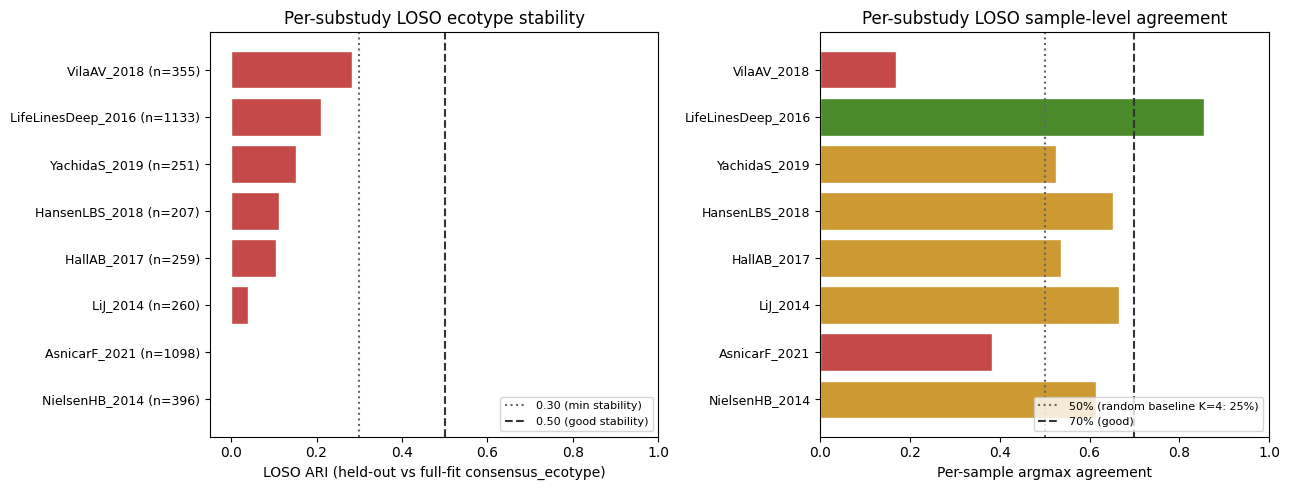

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
order = loso_df.sort_values('ari_held').held_substudy.tolist()
d = loso_df.set_index('held_substudy').loc[order]

# ARI bars
colors = ['#c44a4a' if a < 0.3 else '#cc9933' if a < 0.5 else '#4a8a2a' for a in d.ari_held]
ax1.barh(range(len(d)), d.ari_held, color=colors, edgecolor='white')
ax1.axvline(0.3, ls=':', color='#666', label='0.30 (min stability)')
ax1.axvline(0.5, ls='--', color='#333', label='0.50 (good stability)')
ax1.set_yticks(range(len(d)))
ax1.set_yticklabels([f'{s} (n={n})' for s, n in zip(d.index, d.n_held)], fontsize=9)
ax1.set_xlabel('LOSO ARI (held-out vs full-fit consensus_ecotype)')
ax1.set_title('Per-substudy LOSO ecotype stability')
ax1.legend(fontsize=8, loc='lower right')
ax1.set_xlim(-0.05, 1.0)

# Agreement bars
colors2 = ['#c44a4a' if a < 0.5 else '#cc9933' if a < 0.7 else '#4a8a2a' for a in d.agreement_held]
ax2.barh(range(len(d)), d.agreement_held, color=colors2, edgecolor='white')
ax2.axvline(0.5, ls=':', color='#666', label='50% (random baseline K=4: 25%)')
ax2.axvline(0.7, ls='--', color='#333', label='70% (good)')
ax2.set_yticks(range(len(d)))
ax2.set_yticklabels([f'{s}' for s in d.index], fontsize=9)
ax2.set_xlabel('Per-sample argmax agreement')
ax2.set_title('Per-substudy LOSO sample-level agreement')
ax2.legend(fontsize=8, loc='lower right')
ax2.set_xlim(0, 1.0)

plt.tight_layout()
plt.savefig(FIG_OUT / 'NB04f_loso_stability.png', dpi=120, bbox_inches='tight')
plt.show()


## §6. Save verdict artifact

In [7]:
verdict_obj = {
    'date': '2026-04-24',
    'test': 'Leave-one-substudy-out ecotype stability',
    'n_substudies_tested': int(len(loso_df)),
    'threshold_pass': 0.5,
    'threshold_partial': 0.3,
    'mean_ari': round(float(mean_ari), 3),
    'median_ari': round(float(loso_df.ari_held.median()), 3),
    'ari_range': [round(float(loso_df.ari_held.min()), 3), round(float(loso_df.ari_held.max()), 3)],
    'mean_agreement': round(float(loso_df.agreement_held.mean()), 3),
    'nb04b_bootstrap_ari_median': 0.160,
    'verdict': verdict,
    'per_substudy': loso_df.to_dict(orient='records'),
}
with open(DATA_OUT / 'nb04f_loso_verdict.json', 'w') as f:
    json.dump(verdict_obj, f, indent=2)

print('Saved data/nb04f_loso_stability.tsv + data/nb04f_loso_verdict.json + figures/NB04f_loso_stability.png')


Saved data/nb04f_loso_stability.tsv + data/nb04f_loso_verdict.json + figures/NB04f_loso_stability.png
